# Pixel-wise Image Classification based on Time Series Image Representations

**Course**: INF23306 — Data Structures for Life Sciences  
**Instructor**: Ricardo da Silva Torres  
**Institution**: Artificial Intelligence Group, Wageningen University & Research  
**Contact**: ricardo.dasilvatorres@wur.nl

---
## 1. Problem Context

**Plant phenology** examines recurrent life cycle events in plants and is a key discipline for understanding the effects of climate change. To enhance the accuracy and consistency of phenological observations, recent studies have increasingly adopted new technologies. Among these, digital cameras have proven particularly effective, functioning as **multi-channel imaging sensors** that capture color variations linked to phenological events.

In this project, we monitor the **leaf-changing patterns** of Cerrado-savanna vegetation through daily digital imaging. From these images, we extract color information at the individual plant level and relate it to observed leaf phenological changes. Several vegetation indices associated with different plant species are employed for both pattern analysis and knowledge extraction.

### Main Objective

The main objective of this project is to evaluate a classifier capable of performing **pixel-wise classification** based on vegetation index time series.

---
## 2. Dataset Description

### Image Acquisition

A digital hemispherical lens camera (Mobotix Q24) was set up in an 18m tower in a Cerrado *sensu stricto*, a savanna vegetation located at Itirapina, São Paulo State, Brazil. The camera captures a daily sequence of five JPEG images (at 1280 × 960 pixels of resolution) per hour, from 6:00 to 18:00h (UTC-3). The dataset contains over **2,700 images**, recorded at the end of the dry season, between August 29th and October 3rd, 2011 (day of year 241 to 278), during the main leaf flushing season.

### Regions of Interest (ROIs)

22 ROIs from six plant species were defined:

| Species | ROIs | Color |
|---|---|---|
| *Aspidosperma tomentosum* | 3 | Red |
| *Caryocar brasiliensis* | 4 | Green |
| *Myrcia guianensis* | 2 | Blue |
| *Miconia rubiginosa* | 7 | Orange |
| *Pouteria ramiflora* | 2 | Magenta |
| *Pouteria torta* | 4 | Cyan |

### Vegetation Indices — RGB Chromatic Coordinates (RGBcc)

The normalized chromatic coordinates are the most efficient index for distinguishing plant color from background and for suppressing light variation:

$$r_{cc} = \frac{R}{R + G + B}, \quad g_{cc} = \frac{G}{R + G + B}, \quad b_{cc} = \frac{B}{R + G + B}$$

### Recurrence Plots

The recurrence plot (RP) is defined as the matrix:

$$R_{i,j} = \Theta(\varepsilon - \|\mathbf{x}_i - \mathbf{x}_j\|), \quad i,j = 1, 2, \ldots, N$$

In this project, we retain the **continuous distance values** (gray-level recurrence plots) instead of applying the Heaviside step function. The $r_{cc}$, $g_{cc}$, and $b_{cc}$ recurrence plots are combined to generate RGB images.

- Original time series: **35 time steps** → 35 × 35 pixel RP images
- After upsampling (linear interpolation): **140 time steps** → 140 × 140 pixel RP images

---
## 3. Setup and Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pygame.examples.moveit import HEIGHT, WIDTH
from scipy.interpolate import interp1d
from scipy.spatial.distance import cdist
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from PIL import Image
import os
import glob

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("All libraries imported successfully.")

pygame 2.6.1 (SDL 2.28.4, Python 3.12.7)
Hello from the pygame community. https://www.pygame.org/contribute.html
All libraries imported successfully.


---
## 4. Data Loading

We load the dataset from the `raw/` directory:
- **Images**: from `raw/images/1/` — one image per hour per day (we select the noon image, hour 12, for each day).
- **Masks**: from `raw/masks/` — binary PGM masks defining each ROI.

The time series consists of 37 days (DOY 242–278). For each day, we use the **noon image** (`*_12.jpg`) as the representative observation. We also set up the spatial train/test split by selecting exactly one mask per species for training, and another one for test, keeping the pixel counts as balanced as possible.

In [2]:
# ============================================================
# Configuration
# ============================================================
import os

# Path to the raw dataset (relative to the casework directory)
RAW_DIR = os.path.join("..", "Pixel-wise-Image-Classification-based-on-Time-Series-Image-Representations", "raw")
IMAGES_DIR = os.path.join(RAW_DIR, "images", "1")
MASKS_DIR = os.path.join(RAW_DIR, "masks")

# Hour to select for the daily time series (noon)
SELECTED_HOUR = 12

# Day-of-year range
DOY_START = 242
DOY_END = 278

# Species definitions
SPECIES = {
    0: "A. tomentosum",
    1: "C. brasiliensis",
    2: "M. guianensis",
    3: "M. rubiginosa",
    4: "P. ramiflora",
    5: "P. torta",
}

SPECIES_FULL = {
    0: "Aspidosperma tomentosum",
    1: "Caryocar brasiliensis",
    2: "Myrcia guianensis",
    3: "Miconia rubiginosa",
    4: "Pouteria ramiflora",
    5: "Pouteria torta",
}

# Mask file prefix -> species class index
SPECIES_PREFIX_TO_CLASS = {
    "A.tomentosum": 0,
    "C.brasiliensis": 1,
    "M.guianensis": 2,
    "M.rubiginosa": 3,
    "P.ramiflora": 4,
    "P.torta": 5,
}

print(f"Images directory: {os.path.abspath(IMAGES_DIR)}")
print(f"Masks directory:  {os.path.abspath(MASKS_DIR)}")
print(f"Number of species: {len(SPECIES)}")

Images directory: C:\Users\Gorkem\Desktop\DSLS\Pixel-wise-Image-Classification-based-on-Time-Series-Image-Representations\raw\images\1
Masks directory:  C:\Users\Gorkem\Desktop\DSLS\Pixel-wise-Image-Classification-based-on-Time-Series-Image-Representations\raw\masks
Number of species: 6


### 4.1 Load Image Time Series

We select one image per day (noon) to build a time series across the 37 observation days.

In [3]:
def load_image_time_series(images_dir, doy_start, doy_end, hour=12):
    """
    Load a time series of daily images, selecting one image per day at the
    specified hour.

    Parameters
    ----------
    images_dir : str
        Path to the directory containing the JPEG images.
    doy_start : int
        First day of year (inclusive).
    doy_end : int
        Last day of year (inclusive).
    hour : int
        Hour to select for each day (default: 12 for noon).

    Returns
    -------
    images : np.ndarray
        Array of images, shape (T, H, W, 3), dtype uint8.
    doys : list of int
        Corresponding day-of-year for each loaded image.
    """
    images = []
    doys = []

    for doy in range(doy_start, doy_end + 1):
        filename = f"2011_{doy}_{hour:02d}.jpg"
        filepath = os.path.join(images_dir, filename)

        if os.path.exists(filepath):
            img = np.array(Image.open(filepath))
            images.append(img)
            doys.append(doy)
        else:
            print(f"  Warning: {filename} not found, skipping DOY {doy}")

    return np.array(images), doys


# Load the time series
images, doys = load_image_time_series(IMAGES_DIR, DOY_START, DOY_END, hour=SELECTED_HOUR)

N_TIMESTEPS = len(images)
IMG_H, IMG_W = images[0].shape[:2]

print(f"Loaded {N_TIMESTEPS} images (DOY {doys[0]}–{doys[-1]})")
print(f"Image shape: {images.shape}")
print(f"Image resolution: {IMG_W} x {IMG_H} pixels")

Loaded 37 images (DOY 242–278)
Image shape: (37, 960, 1280, 3)
Image resolution: 1280 x 960 pixels


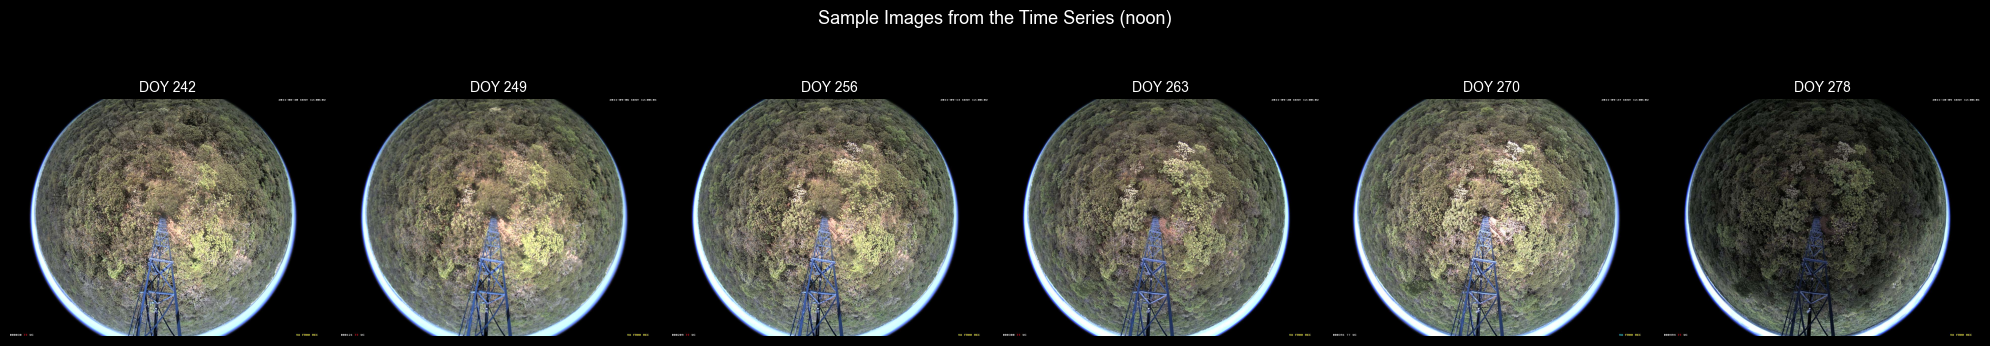

In [4]:
# Visualize a few sample images from the time series
sample_indices = np.linspace(0, N_TIMESTEPS - 1, 6, dtype=int)

fig, axes = plt.subplots(1, 6, figsize=(20, 4))
for ax, idx in zip(axes, sample_indices):
    ax.imshow(images[idx])
    ax.set_title(f"DOY {doys[idx]}", fontsize=10)
    ax.axis("off")

fig.suptitle("Sample Images from the Time Series (noon)", fontsize=13)
plt.tight_layout()
plt.show()

### 4.2 Load Segmentation Masks

Each mask is a binary PGM image (0 = background, 255 = ROI). We parse the filenames to determine the species and ROI ID.

In [5]:
def load_masks(masks_dir, species_prefix_to_class):
    """
    Load all segmentation masks and organize them by species.

    Parameters
    ----------
    masks_dir : str
        Path to the directory containing PGM mask files.
    species_prefix_to_class : dict
        Mapping from mask filename prefix to species class index.

    Returns
    -------
    masks : list of dict
        Each dict contains:
        - 'species_class': int, species class index
        - 'species_name': str, filename prefix (e.g., 'A.tomentosum')
        - 'roi_id': int, ROI number
        - 'mask': np.ndarray, binary mask (H, W), True where ROI
        - 'n_pixels': int, number of ROI pixels
        - 'filename': str, original filename
    """
    masks = []
    mask_files = sorted(glob.glob(os.path.join(masks_dir, "*.pgm")))

    for filepath in mask_files:
        filename = os.path.basename(filepath)
        name_no_ext = filename.replace(".pgm", "")

        # Parse: "A.tomentosum_5" -> species="A.tomentosum", roi_id=5
        parts = name_no_ext.rsplit("_", 1)
        species_name = parts[0]
        roi_id = int(parts[1])

        if species_name not in species_prefix_to_class:
            print(f"  Warning: Unknown species prefix '{species_name}' in {filename}")
            continue

        species_class = species_prefix_to_class[species_name]
        mask_arr = np.array(Image.open(filepath))
        binary_mask = mask_arr > 0  # Convert to boolean

        masks.append({
            "species_class": species_class,
            "species_name": species_name,
            "roi_id": roi_id,
            "mask": binary_mask,
            "n_pixels": int(np.sum(binary_mask)),
            "filename": filename,
        })

    return masks


# Load all masks
all_masks = load_masks(MASKS_DIR, SPECIES_PREFIX_TO_CLASS)

print(f"Loaded {len(all_masks)} ROI masks:\n")
print(f"{'Species':<25s} {'ROI':>4s} {'Pixels':>8s}")
print("-" * 40)
for m in all_masks:
    print(f"{SPECIES_FULL[m['species_class']]:<25s} {m['roi_id']:>4d} {m['n_pixels']:>8d}")

Loaded 22 ROI masks:

Species                    ROI   Pixels
----------------------------------------
Aspidosperma tomentosum     11     1064
Aspidosperma tomentosum      5     1486
Aspidosperma tomentosum      7     1459
Caryocar brasiliensis        2     6601
Caryocar brasiliensis       23     7405
Caryocar brasiliensis       29     2455
Caryocar brasiliensis       31     3178
Myrcia guianensis            1     1706
Myrcia guianensis           21     1527
Miconia rubiginosa          15     1028
Miconia rubiginosa          24     5555
Miconia rubiginosa          28      836
Miconia rubiginosa          32     2111
Miconia rubiginosa          34     1582
Miconia rubiginosa           4     2064
Miconia rubiginosa           6     3069
Pouteria ramiflora          10     3001
Pouteria ramiflora           8     1283
Pouteria torta              17     2748
Pouteria torta              18     2224
Pouteria torta               3     3552
Pouteria torta               9     4028


### 4.3 Train / Test Split by ROI Assignment

To evaluate the classifier on spatially distinct regions it has never seen during training, we perform the train/test split at the **ROI level**: for each species, we select **exactly one** ROI mask for the training set and **exactly one** ROI mask for the test set.

We balance the pixel counts per species and overall as closely as possible:

| Species | Train ROI (pixels) | Test ROI (pixels) |
|---|---|---|
| *Aspidosperma tomentosum* | ROI 5 (1,486 px) | ROI 7 (1,459 px) |
| *Caryocar brasiliensis* | ROI 31 (3,178 px) | ROI 29 (2,455 px) |
| *Myrcia guianensis* | ROI 1 (1,706 px) | ROI 21 (1,527 px) |
| *Miconia rubiginosa* | ROI 4 (2,064 px) | ROI 32 (2,111 px) |
| *Pouteria ramiflora* | ROI 8 (1,283 px) | ROI 10 (3,001 px) |
| *Pouteria torta* | ROI 9 (4,028 px) | ROI 3 (3,552 px) |

- **Total Training Pixels**: 13,745 (49.3%)
- **Total Testing Pixels**: 14,105 (50.7%)

In [6]:
# ============================================================
# Train / Test split by ROI assignment
# ============================================================

# Define exactly one train mask and exactly one test mask per species
TRAIN_ROIS = {
    "A.tomentosum": [5],
    "C.brasiliensis": [31],
    "M.guianensis": [1],
    "M.rubiginosa": [4],
    "P.ramiflora": [8],
    "P.torta": [9],
}

TEST_ROIS = {
    "A.tomentosum": [7],
    "C.brasiliensis": [29],
    "M.guianensis": [21],
    "M.rubiginosa": [32],
    "P.ramiflora": [10],
    "P.torta": [3],
}


def split_masks_by_roi(all_masks, train_rois, test_rois):
    """
    Split the loaded masks into train and test sets based on ROI assignments.

    Parameters
    ----------
    all_masks : list of dict
        All loaded mask entries.
    train_rois : dict
        Species -> list of ROI IDs for training.
    test_rois : dict
        Species -> list of ROI IDs for testing.

    Returns
    -------
    train_masks : list of dict
        Masks assigned to the training set.
    test_masks : list of dict
        Masks assigned to the test set.
    """
    train_masks = []
    test_masks = []

    for m in all_masks:
        species = m["species_name"]
        roi_id = m["roi_id"]

        if species in train_rois and roi_id in train_rois[species]:
            train_masks.append(m)
        elif species in test_rois and roi_id in test_rois[species]:
            test_masks.append(m)

    return train_masks, test_masks


train_masks, test_masks = split_masks_by_roi(all_masks, TRAIN_ROIS, TEST_ROIS)

print(f"Training ROIs: {len(train_masks)}")
print(f"Test ROIs:     {len(test_masks)}")

Training ROIs: 6
Test ROIs:     6


In [7]:
# Summary of train/test split pixel counts
print(f"\n{'Split':>7s} | {'Species':<25s} | {'ROI':>4s} | {'Pixels':>7s}")
print("-" * 55)

for m in train_masks:
    print(f"{'TRAIN':>7s} | {SPECIES_FULL[m['species_class']]:<25s} | {m['roi_id']:>4d} | {m['n_pixels']:>7d}")

print("-" * 55)

for m in test_masks:
    print(f"{'TEST':>7s} | {SPECIES_FULL[m['species_class']]:<25s} | {m['roi_id']:>4d} | {m['n_pixels']:>7d}")

# Pixel count summary per species
print("\n" + "=" * 60)
print(f"{'Species':<25s} | {'Train px':>10s} | {'Test px':>10s} | {'Ratio':>6s}")
print("-" * 60)

for cls_id in range(6):
    train_px = sum(m["n_pixels"] for m in train_masks if m["species_class"] == cls_id)
    test_px = sum(m["n_pixels"] for m in test_masks if m["species_class"] == cls_id)
    total = train_px + test_px
    ratio = f"{train_px / total:.0%}" if total > 0 else "N/A"
    print(f"{SPECIES_FULL[cls_id]:<25s} | {train_px:>10d} | {test_px:>10d} | {ratio:>6s}")

total_train_px = sum(m["n_pixels"] for m in train_masks)
total_test_px = sum(m["n_pixels"] for m in test_masks)
grand_total = total_train_px + total_test_px
print("-" * 60)
print(f"{'Total (All Species)':<25s} | {total_train_px:>10d} | {total_test_px:>10d} | {total_train_px/grand_total:>6.1%}")


  Split | Species                   |  ROI |  Pixels
-------------------------------------------------------
  TRAIN | Aspidosperma tomentosum   |    5 |    1486
  TRAIN | Caryocar brasiliensis     |   31 |    3178
  TRAIN | Myrcia guianensis         |    1 |    1706
  TRAIN | Miconia rubiginosa        |    4 |    2064
  TRAIN | Pouteria ramiflora        |    8 |    1283
  TRAIN | Pouteria torta            |    9 |    4028
-------------------------------------------------------
   TEST | Aspidosperma tomentosum   |    7 |    1459
   TEST | Caryocar brasiliensis     |   29 |    2455
   TEST | Myrcia guianensis         |   21 |    1527
   TEST | Miconia rubiginosa        |   32 |    2111
   TEST | Pouteria ramiflora        |   10 |    3001
   TEST | Pouteria torta            |    3 |    3552

Species                   |   Train px |    Test px |  Ratio
------------------------------------------------------------
Aspidosperma tomentosum   |       1486 |       1459 |    50%
Caryocar brasi

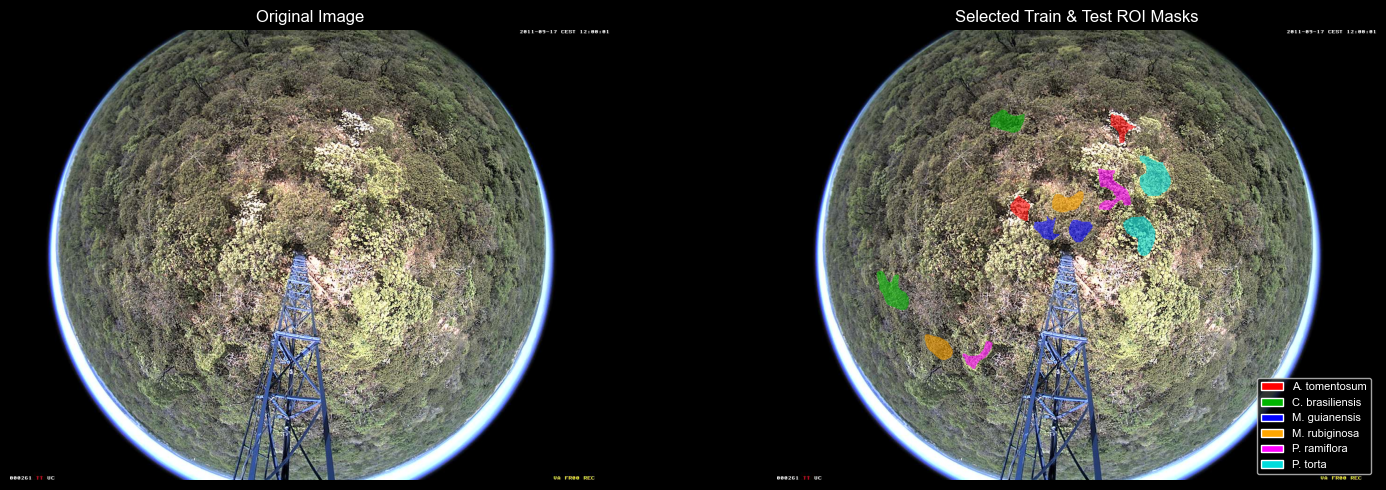

In [8]:
# Visualize the masks overlaid on a sample image
COLORS = {
    0: [255, 0, 0],       # Red - A. tomentosum
    1: [0, 180, 0],       # Green - C. brasiliensis
    2: [0, 0, 255],       # Blue - M. guianensis
    3: [255, 165, 0],     # Orange - M. rubiginosa
    4: [255, 0, 255],     # Magenta - P. ramiflora
    5: [0, 220, 220],     # Cyan - P. torta
}

overlay = images[N_TIMESTEPS // 2].copy()
for m in train_masks + test_masks:
    color = COLORS[m["species_class"]]
    overlay[m["mask"]] = (
        0.4 * overlay[m["mask"]] + 0.6 * np.array(color)
    ).astype(np.uint8)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
ax1.imshow(images[N_TIMESTEPS // 2])
ax1.set_title("Original Image")
ax1.axis("off")

ax2.imshow(overlay)
ax2.set_title("Selected Train & Test ROI Masks")
ax2.axis("off")

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=np.array(COLORS[i]) / 255, label=SPECIES[i])
    for i in range(6)
]
ax2.legend(handles=legend_elements, loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()

---
## 5. Compute RGB Chromatic Coordinates

Compute the normalized chromatic coordinates ($r_{cc}$, $g_{cc}$, $b_{cc}$) for each pixel in the time series.

In [9]:
def compute_chromatic_coordinates(image):
    """
    Compute the RGB chromatic coordinates for a given image.

    Parameters
    ----------
    image : np.ndarray
        Input image of shape (H, W, 3) with R, G, B channels.

    Returns
    -------
    r_cc : np.ndarray
        Red chromatic coordinate, shape (H, W).
    g_cc : np.ndarray
        Green chromatic coordinate, shape (H, W).
    b_cc : np.ndarray
        Blue chromatic coordinate, shape (H, W).
    """
    # TODO: Implement chromatic coordinate computation
    # r_cc = R / (R + G + B)
    # g_cc = G / (R + G + B)
    # b_cc = B / (R + G + B)
    # Handle division by zero (e.g., black pixels)
    H, W, _ = image.shape

    R = image[:, :, 0].astype(float)
    G = image[:, :, 1].astype(float)
    B = image[:, :, 2].astype(float)

    total_intensity = R + G + B

    safe_intensity = np.where(total_intensity == 0, 1, total_intensity)

    r_cc = R / safe_intensity
    g_cc = G / safe_intensity
    b_cc = B / safe_intensity

    return r_cc, g_cc, b_cc

In [10]:
# TODO: Apply the chromatic coordinate computation to the entire time series
# For each ROI, extract the time series of r_cc, g_cc, b_cc values
chromatic_stack = np.zeros((N_TIMESTEPS, IMG_H, IMG_W, 3), dtype=np.float32)

for t, img in enumerate(images):
    r_cc, g_cc, b_cc = compute_chromatic_coordinates(img)
    chromatic_stack[t, :, :, 0] = r_cc
    chromatic_stack[t, :, :, 1] = g_cc
    chromatic_stack[t, :, :, 2] = b_cc

print(f"Chromatic stack shape: {chromatic_stack.shape}")  # (37, H, W, 3)



Chromatic stack shape: (37, 960, 1280, 3)


---
## 6. Extract Time Series per ROI

For each ROI, compute the mean chromatic coordinate values across the region at each time step, resulting in a 1D time series per channel per ROI.

In [20]:
def extract_pixel_time_series(my_images, h, w):
    num_of_images = my_images.shape[0]
    height = my_images.shape[1]
    width = my_images.shape[2]

    # np arrays with 1D shape
    r_px_ts = np.zeros((num_of_images,), dtype=np.float32)
    g_px_ts = np.zeros((num_of_images,), dtype=np.float32)
    b_px_ts = np.zeros((num_of_images,), dtype=np.float32)

    for t, image in enumerate(my_images):
        # Calculates the means in C level, so it is a lot faster than a manual loop
        r_px_ts[t] = image[h,w,0]
        g_px_ts[t] = image[h,w,1]
        b_px_ts[t] = image[h,w,2]

    return r_px_ts, g_px_ts, b_px_ts


def extract_roi_time_series(my_images, mask):
    """
    Extract the mean chromatic coordinate time series for a given ROI.

    Parameters
    ----------
    images : list of np.ndarray
        List of images (each of shape (H, W, 3)) forming the time series.
    mask : np.ndarray
        Binary mask of shape (H, W) defining the ROI.

    Returns
    -------
    r_cc_ts : np.ndarray
        Time series of mean r_cc values, shape (T,).
    g_cc_ts : np.ndarray
        Time series of mean g_cc values, shape (T,).
    b_cc_ts : np.ndarray
        Time series of mean b_cc values, shape (T,).
    """
    # TODO: Implement time series extraction
    # Some shape data that might be useful
    num_of_images = my_images.shape[0]
    height = my_images.shape[1]
    width = my_images.shape[2]

    # np arrays with 1D shape
    r_cc_ts = np.zeros((num_of_images,), dtype=np.float32)
    g_cc_ts = np.zeros((num_of_images,), dtype=np.float32)
    b_cc_ts = np.zeros((num_of_images,), dtype=np.float32)

    # Enumerated for loop to keep the indices of the images
    for t, image in enumerate(my_images):
        # Calculates the means in C level, so it is a lot faster than a manual loop
        r_cc_ts[t] = np.mean(image[:,:,0][mask["mask"]])
        g_cc_ts[t] = np.mean(image[:,:,1][mask["mask"]])
        b_cc_ts[t] = np.mean(image[:,:,2][mask["mask"]])

        #print("Finished image", t)

    print("Finished a mask")
    return r_cc_ts, g_cc_ts, b_cc_ts

'''# Enumerated for loop to keep the indices of the images, works way slower so we do not use this!!!
for t, image in enumerate(my_images):
    # Reset all the values for each image before entering the loop
    total_red_value = 0
    total_green_value = 0
    total_blue_value = 0
    total_pixels = 0
    for h in range(height):
        for w in range(width):
            # Calculate the mean where mask = 1
            if mask["mask"][h,w]:
                total_red_value += image[h,w,0]
                total_green_value += image[h,w,1]
                total_blue_value += image[h,w,2]
                total_pixels += 1
    #Calculate the means and write into the time series
    mean_red_value = total_red_value / total_pixels
    mean_green_value = total_green_value / total_pixels
    mean_blue_value = total_blue_value / total_pixels


    r_cc_ts[t] = mean_red_value
    g_cc_ts[t] = mean_green_value
    b_cc_ts[t] = mean_blue_value

    #print("Finished image", t)

print("Finished a mask")
return r_cc_ts, g_cc_ts, b_cc_ts

'''







# TODO: Extract time series for all ROIs and store with their labels
number_of_masks = len(all_masks)
labels = [] # list of corresponding species labels
time_series_data = np.zeros((number_of_masks, N_TIMESTEPS, 3))  # list of (r_cc_ts, g_cc_ts, b_cc_ts) tuples
for i, mask in enumerate(all_masks):
    time_series_data[i,:, 0], time_series_data[i, :, 1], time_series_data[i, :, 2] = extract_roi_time_series(chromatic_stack, mask)
    labels.append(all_masks[i]["species_name"])
print(labels)




Finished a mask
Finished a mask
Finished a mask
Finished a mask
Finished a mask
Finished a mask
Finished a mask
Finished a mask
Finished a mask
Finished a mask
Finished a mask
Finished a mask
Finished a mask
Finished a mask
Finished a mask
Finished a mask
Finished a mask
Finished a mask
Finished a mask
Finished a mask
Finished a mask
Finished a mask
['A.tomentosum', 'A.tomentosum', 'A.tomentosum', 'C.brasiliensis', 'C.brasiliensis', 'C.brasiliensis', 'C.brasiliensis', 'M.guianensis', 'M.guianensis', 'M.rubiginosa', 'M.rubiginosa', 'M.rubiginosa', 'M.rubiginosa', 'M.rubiginosa', 'M.rubiginosa', 'M.rubiginosa', 'P.ramiflora', 'P.ramiflora', 'P.torta', 'P.torta', 'P.torta', 'P.torta']


---
## Exercise 1: Construct Recurrence Plot Images

Build recurrence plot images from the vegetation index time series as described in the dataset preparation procedure.

**Steps:**
1. Upsample each time series from 35 to 140 time steps using linear interpolation.
2. Compute the gray-level recurrence plot (continuous distance matrix) for each channel.
3. Combine the $r_{cc}$, $g_{cc}$, and $b_{cc}$ recurrence plots into RGB images.

In [12]:
def upsample_time_series(ts, original_length=37, target_length=140):
    """
    Upsample a time series using linear interpolation.

    Parameters
    ----------
    ts : np.ndarray
        Original time series of shape (original_length,).
    original_length : int
        Number of original time steps.
    target_length : int
        Number of target time steps after upsampling.

    Returns
    -------
    ts_upsampled : np.ndarray
        Upsampled time series of shape (target_length,).
    """
    # TODO: Implement linear interpolation upsampling
    # Hint: use scipy.interpolate.interp1d

    x = np.linspace(0, 1, original_length)
    x_new = np.linspace(0, 1, num = target_length)

    f = interp1d (x, ts, kind='linear')
    ts_upsampled = f(x_new)

    return ts_upsampled

In [13]:
def compute_recurrence_plot(ts):
    """
    Compute the gray-level recurrence plot (distance matrix) for a time series.

    Parameters
    ----------
    ts : np.ndarray
        Time series of shape (N,).

    Returns
    -------
    rp : np.ndarray
        Recurrence plot (distance matrix) of shape (N, N).
    """
    # TODO: Compute the pairwise Euclidean distance matrix
    # R_{i,j} = ||x_i - x_j||
    # Hint: use scipy.spatial.distance.cdist or manual computation

    ts_reshaped = ts.reshape(len(ts), 1)
    return cdist (ts_reshaped, ts_reshaped, 'euclidean')



In [17]:
def create_rgb_recurrence_plot(r_cc_ts, g_cc_ts, b_cc_ts):
    """
    Create an RGB recurrence plot image by combining the recurrence plots
    of the three chromatic coordinate channels.

    Parameters
    ----------
    r_cc_ts : np.ndarray
        Red chromatic coordinate time series, shape (N,).
    g_cc_ts : np.ndarray
        Green chromatic coordinate time series, shape (N,).
    b_cc_ts : np.ndarray
        Blue chromatic coordinate time series, shape (N,).

    Returns
    -------
    rgb_rp : np.ndarray
        RGB recurrence plot image of shape (N, N, 3).
    """
    # TODO: Implement the following steps:
    # 1. Upsample each time series
    red_upsampled = upsample_time_series(r_cc_ts)
    green_upsampled = upsample_time_series(g_cc_ts)
    blue_upsampled = upsample_time_series(b_cc_ts)

    # 2. Compute recurrence plot for each channel
    red_rp = compute_recurrence_plot(red_upsampled)
    green_rp = compute_recurrence_plot(green_upsampled)
    blue_rp = compute_recurrence_plot(blue_upsampled)


    # 3. Normalize each RP to [0, 255]
    red_rpn = ((red_rp - red_rp.min()) /(red_rp.max() - red_rp.min()) * 255).astype(int)
    green_rpn = ((green_rp - green_rp.min()) /(green_rp.max() - green_rp.min()) * 255).astype(int)
    blue_rpn = ((blue_rp - blue_rp.min()) /(blue_rp.max() - blue_rp.min()) * 255).astype(int)


    # 4. Stack into an RGB image
    RGB_image = np.zeros((140, 140, 3))
    RGB_image[:, :, 0] = red_rpn.astype(int)
    RGB_image[:, :, 1] = green_rpn.astype(int)
    RGB_image[:, :, 2] = blue_rpn.astype(int)

    return RGB_image

In [19]:
# TODO: Build the full dataset of recurrence plot images
# rp_images = []  # list of RGB recurrence plot images
# rp_labels = []  # list of corresponding species labels

rp_labels = []
rp_images = []
for i, mask in enumerate(all_masks):
    roi_ts = chromatic_stack[:, mask["mask"], :]
    for px in range(roi_ts.shape[1]):
        r_cc_ts = roi_ts[:, px, 0]
        g_cc_ts = roi_ts[:, px, 1]
        b_cc_ts = roi_ts[:, px, 2]
        rp_images.append(create_rgb_recurrence_plot(r_cc_ts, g_cc_ts, b_cc_ts))
        rp_labels.append(mask["species_class"])

# for each ROI:
#     1. Get the r_cc, g_cc, b_cc time series
#     2. Create the RGB recurrence plot
#     3. Append to the dataset


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


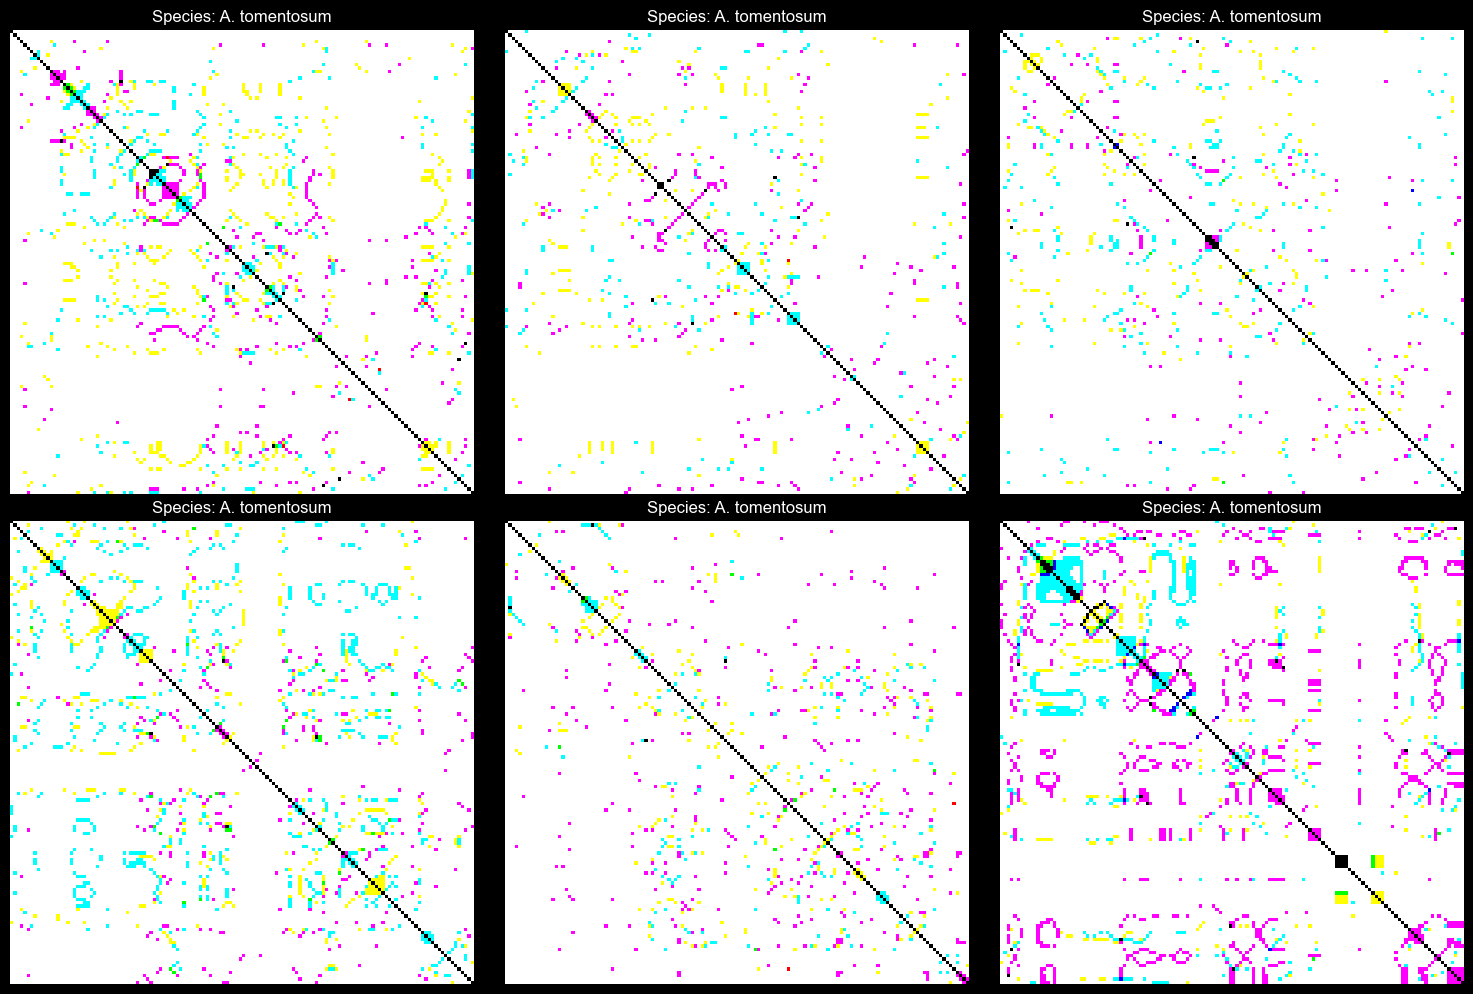

In [16]:
# TODO: Visualize a few example recurrence plot images
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(rp_images[i])
    ax.set_title(f"Species: {SPECIES[rp_labels[i]]}")
    ax.axis("off")
plt.tight_layout()
plt.show()




---
## Exercise 2: Split the Data

Since we have already performed the spatial split at the ROI level (Section 4.3), our **test set** is defined by the independent test ROIs, ensuring no spatial data leakage.

In this exercise, you should:
1. Split the pixel-wise features and labels from the **training ROIs** into **training** and **validation** subsets (e.g., 80% train, 20% validation) using a stratified split.
2. Ensure you have corresponding stratified subsets for both the raw time-series data and the recurrence plot images.

In [26]:
# TODO: Split the raw time-series training data (extracted in Exercise 3) into train and validation subsets
# Use stratified splitting to maintain class proportions (e.g., 80% train, 20% validation)
# Keep the test set (from the test ROIs) separate
X_ts_trainval = []
y_ts_trainval = []
X_ts_test = []
y_ts_test = []


ts_data_train_pixels = np.ndarray((total_train_px, 3, 140), dtype=np.float32)
mask_of_pixel = np.ndarray((total_train_px,), dtype=np.uint8)


counter = 0

for mask in train_masks:
    for h in range(IMG_H):
        for w in range(IMG_W):
            if mask["mask"][h,w]:
                raw_r, raw_g, raw_b = extract_pixel_time_series(chromatic_stack, h, w)
                ts_data_train_pixels[counter, 0, :], ts_data_train_pixels[counter, 1, :], ts_data_train_pixels[counter, 2, :] = upsample_time_series(raw_r), upsample_time_series(raw_g), upsample_time_series(raw_b)

                mask_of_pixel[counter] = mask["roi_id"]
                counter += 1


for px in range(total_train_px):
    X_ts_trainval.append(ts_data_train_pixels[i])
    y_ts_trainval.append(all_masks[mask_of_pixel[i]]["species_name"])
for i, mask in enumerate(all_masks):
    if mask in test_masks:
        X_ts_test.append(time_series_data[i])
        y_ts_test.append(all_masks[i]["species_name"])


X_ts_train, X_ts_val, y_ts_train, y_ts_val = train_test_split(X_ts_trainval, y_ts_trainval, test_size=0.2, random_state=RANDOM_STATE, stratify=y_ts_trainval)

print(f"Time Series — Train: {len(X_ts_train)}, Val: {len(X_ts_val)}, Test: {len(X_ts_test)}")

Time Series — Train: 10996, Val: 2749, Test: 6


In [ ]:
# TODO: Split the recurrence plot training data (extracted in Exercise 4) into train and validation subsets
# Use the same stratified splitting strategy (e.g., 80% train, 20% validation)
# Keep the test set (from the test ROIs) separate

# X_rp_train, X_rp_val, y_rp_train, y_rp_val = train_test_split(
#     X_rp_trainval, y_rp_trainval, test_size=0.2, random_state=RANDOM_STATE, stratify=y_rp_trainval
# )

# print(f"Recurrence Plots — Train: {len(X_rp_train)}, Val: {len(X_rp_val)}, Test: {len(X_rp_test)}")

---
## Exercise 3: K-NN on Raw Time Series

Evaluate the performance of a **K-nearest neighbors (K-NN)** classifier using the raw time-series data as input.

In [ ]:
# TODO: Prepare the pixel-wise feature vectors from the raw time series for both train and test sets.
# For each pixel in each mask:
#     1. Get its r_cc, g_cc, b_cc time series (length T) from the computed chromatic coordinates.
#     2. Concatenate/flatten the channels into a single feature vector of length 3 * T.
#     3. Store the feature vectors and class labels.
#
# Hint:
# - X_ts_trainval should have shape (n_train_pixels, 3 * T) where n_train_pixels is the sum of pixels in all train masks.
# - X_ts_test should have shape (n_test_pixels, 3 * T) where n_test_pixels is the sum of pixels in all test masks.

# X_ts_trainval = ...
# y_ts_trainval = ...
# X_ts_test = ...
# y_ts_test = ...


In [ ]:
# TODO: Train and tune the K-NN classifier on the raw time-series data using the validation set.
# Tune K using the validation set and evaluate the best model on the test set.
# Print the classification report.

# k_values = [1, 3, 5, 7, 9, 11, 15]
# val_accuracies = []
# for k in k_values:
#     knn = KNeighborsClassifier(n_neighbors=k)
#     knn.fit(X_ts_train, y_ts_train)
#     y_val_pred = knn.predict(X_ts_val)
#     val_accuracies.append(accuracy_score(y_ts_val, y_val_pred))
#     print(f"K={k}: Validation Accuracy = {val_accuracies[-1]:.4f}")

# best_k_ts = k_values[np.argmax(val_accuracies)]
# print(f"\nBest K for time series: {best_k_ts}")
# knn_ts = KNeighborsClassifier(n_neighbors=best_k_ts)
# knn_ts.fit(X_ts_train, y_ts_train)
# y_ts_test_pred = knn_ts.predict(X_ts_test)
# print(classification_report(y_ts_test, y_ts_test_pred, target_names=list(SPECIES_FULL.values())))


In [ ]:
# TODO: Plot confusion matrix for time-series K-NN

# cm_ts = confusion_matrix(y_ts_test, y_ts_test_pred)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm_ts, display_labels=list(SPECIES.values()))
# fig, ax = plt.subplots(figsize=(10, 8))
# disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
# ax.set_title("Confusion Matrix — K-NN on Raw Time Series")
# plt.tight_layout()
# plt.show()


---
## Exercise 4: K-NN on Recurrence Plot Images

Evaluate the performance of a **K-nearest neighbors (K-NN)** classifier using recurrence plot images as input.

In [ ]:
# TODO: Prepare the pixel-wise feature vectors from recurrence plot images for both train and test sets.
# For each pixel in each mask:
#     1. Get its r_cc, g_cc, b_cc time series.
#     2. Create the RGB recurrence plot image (shape 140 x 140 x 3).
#     3. Flatten the image into a 1D feature vector of length 140 * 140 * 3.
#     4. Store the feature vectors and class labels.
#
# Hint:
# - X_rp_trainval should have shape (n_train_pixels, 140 * 140 * 3).
# - X_rp_test should have shape (n_test_pixels, 140 * 140 * 3).

# X_rp_trainval = ...
# y_rp_trainval = ...
# X_rp_test = ...
# y_rp_test = ...


In [ ]:
# TODO: Train and tune the K-NN classifier on the recurrence plot data using the validation set.
# Tune K using the validation set and evaluate the best model on the test set.
# Print the classification report.

# k_values = [1, 3, 5, 7, 9, 11, 15]
# val_accuracies_rp = []
# for k in k_values:
#     knn = KNeighborsClassifier(n_neighbors=k)
#     knn.fit(X_rp_train, y_rp_train)
#     y_val_pred = knn.predict(X_rp_val)
#     val_accuracies_rp.append(accuracy_score(y_rp_val, y_val_pred))
#     print(f"K={k}: Validation Accuracy = {val_accuracies_rp[-1]:.4f}")

# best_k_rp = k_values[np.argmax(val_accuracies_rp)]
# print(f"\nBest K for recurrence plots: {best_k_rp}")
# knn_rp = KNeighborsClassifier(n_neighbors=best_k_rp)
# knn_rp.fit(X_rp_train, y_rp_train)
# y_rp_test_pred = knn_rp.predict(X_rp_test)
# print(classification_report(y_rp_test, y_rp_test_pred, target_names=list(SPECIES_FULL.values())))


In [ ]:
# TODO: Plot confusion matrix for recurrence plot K-NN

# cm_rp = confusion_matrix(y_rp_test, y_rp_test_pred)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm_rp, display_labels=list(SPECIES.values()))
# fig, ax = plt.subplots(figsize=(10, 8))
# disp.plot(ax=ax, cmap="Greens", xticks_rotation=45)
# ax.set_title("Confusion Matrix — K-NN on Recurrence Plot Images")
# plt.tight_layout()
# plt.show()


---
## Exercise 5: Compare and Analyze Results

Compare the classification performance between the two approaches using appropriate metrics: **accuracy**, **precision**, **recall**, and **F1-score**.

In [ ]:
# TODO: Compute summary metrics for both approaches

def compute_metrics(y_true, y_pred):
    """
    Compute classification metrics.

    Parameters
    ----------
    y_true : array-like
        True labels.
    y_pred : array-like
        Predicted labels.

    Returns
    -------
    metrics : dict
        Dictionary with accuracy, precision, recall, and F1-score.
    """
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (macro)": precision_score(y_true, y_pred, average="macro"),
        "Recall (macro)": recall_score(y_true, y_pred, average="macro"),
        "F1-score (macro)": f1_score(y_true, y_pred, average="macro"),
    }


# metrics_ts = compute_metrics(y_ts_test, y_ts_test_pred)
# metrics_rp = compute_metrics(y_rp_test, y_rp_test_pred)

# print(f"{'Metric':<25} {'Time Series':>15} {'Recurrence Plot':>15}")
# print("=" * 55)
# for metric_name in metrics_ts:
#     print(f"{metric_name:<25} {metrics_ts[metric_name]:>15.4f} {metrics_rp[metric_name]:>15.4f}")


In [ ]:
# TODO: Create a comparative bar chart of the metrics

# metric_names = list(metrics_ts.keys())
# ts_values = list(metrics_ts.values())
# rp_values = list(metrics_rp.values())

# x = np.arange(len(metric_names))
# width = 0.35

# fig, ax = plt.subplots(figsize=(12, 6))
# bars1 = ax.bar(x - width / 2, ts_values, width, label="Raw Time Series", color="steelblue")
# bars2 = ax.bar(x + width / 2, rp_values, width, label="Recurrence Plots", color="seagreen")

# ax.set_ylabel("Score")
# ax.set_title("K-NN Performance Comparison: Time Series vs. Recurrence Plots")
# ax.set_xticks(x)
# ax.set_xticklabels(metric_names, rotation=15)
# ax.legend()
# ax.set_ylim(0, 1.1)
# ax.grid(axis="y", alpha=0.3)

# # Add value labels on bars
# for bar in bars1:
#     ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
#             f"{bar.get_height():.3f}", ha="center", fontsize=9)
# for bar in bars2:
#     ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
#             f"{bar.get_height():.3f}", ha="center", fontsize=9)

# plt.tight_layout()
# plt.show()


In [ ]:
# TODO: Side-by-side confusion matrices

# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# ConfusionMatrixDisplay(
#     confusion_matrix=cm_ts, display_labels=list(SPECIES.values())
# ).plot(ax=ax1, cmap="Blues", xticks_rotation=45)
# ax1.set_title("K-NN on Raw Time Series")

# ConfusionMatrixDisplay(
#     confusion_matrix=cm_rp, display_labels=list(SPECIES.values())
# ).plot(ax=ax2, cmap="Greens", xticks_rotation=45)
# ax2.set_title("K-NN on Recurrence Plots")

# plt.tight_layout()
# plt.show()


---
## Exercise 6: Critical Reflection

Reflect on the use of image-based representations, such as matrix-structured recurrence plots, for encoding time-series data.

### Discussion Points

Address the following aspects in your analysis:

1. **Strengths of recurrence plot representations**
   - How do recurrence plots capture temporal dynamics that raw time series might not reveal?
   - What patterns (e.g., periodicity, regime changes) become more visible in the RP domain?

2. **Limitations of recurrence plot representations**
   - What information might be lost during the transformation?
   - How sensitive are recurrence plots to noise, time series length, and parameter choices (e.g., ε)?

3. **Data storage implications**
   - Compare the storage requirements of raw time series vs. recurrence plot images.
   - How does upsampling (35 → 140 time steps) affect storage?

4. **Computational efficiency**
   - What is the computational cost of generating recurrence plots?
   - How does the feature dimensionality of flattened RP images compare to raw time series?

5. **Feature extraction and machine learning**
   - Why might image-based representations benefit from convolutional neural networks (CNNs)?
   - How does K-NN performance compare across the two representations and why?

In [ ]:
# TODO: Write your reflections here as comments or markdown
# You can also add quantitative analyses to support your discussion

# Example: Compare storage requirements
# ts_size = ...   # size in bytes for raw time series
# rp_size = ...   # size in bytes for recurrence plot images
# print(f"Storage ratio (RP / TS): {rp_size / ts_size:.1f}x")

# Example: Compare feature dimensionality
# ts_dim = ...   # number of features in raw time series
# rp_dim = ...   # number of features in flattened RP image
# print(f"Feature dimensionality — TS: {ts_dim}, RP: {rp_dim}")

---
### Your Reflection

*Write your discussion and analysis here...*


